# Compute position of the Polar Front in the Kerguelen region (on a yearly basis)

### Method of computation: from Azarian et al. (2024)

##### Input:
- GLORYS12V1 sea temperature files (from CMEMS, GLOBAL_MULTIYEAR_PHY_001_030)

- Daily files: extracted for the advection period (for each year, identify the first and last days of the advection experiments, then extract these)

- Region: [60,80]°E, [45,55]°S (north Kerguelen-centered)

##### Method:

Daily (each timestep) and for each grid point:
- extract the vertical temperature profile between 100 and 400m
- determine the minimum temperature
- determine whether this minimum temperature is located at a depth <350m
- & whether it is inferior to 3°C

- if the grid cell respects these two criteria (depth of the minimum and minimum T value), its mask gets a 1, if not it gets a 0

Then:
- average over the time period (technically 182 days) => gives the probability of presence of Winter Waters
- determine the northernmost extent of 80% WW presence probability : gives the location of the PF

Repeat for all years.

In [167]:
# Load modules
file_modules="/home/analivaev/Documents/THESE/Scripts/CMIP6/modules/import_modules.py"
with open(file_modules) as file:
    exec(file.read())
    
from datetime import datetime

### Read files

In [168]:
def find_date(data,year,week_number):
    

    time=data.variables['time'][:] # epoch thing (seconds since 1970)
    
    time_dates=[datetime.fromtimestamp(int(day)).date() for day in time]
    
    d = "{}-W{}".format(year,week_number) # use of datetime to find date corresponding to a week number
    r = datetime.strptime(d + '-4', "%Y-W%W-%w") # select Thursday of week number
    print(r.date()) # starting date

    
    index=np.where(np.array(time_dates)==r.date())[0][0]

    return(index)
    

In [169]:
def compute_WW_presence_mask(data,year,week_start,week_end):
    
    lon,lat=data.variables['longitude'][:],data.variables['latitude'][:]
    depth=data.variables['depth'][:]
    time=data.variables['time'][:]

    start_date=find_date(data,year,week_start) # week 25 technically
    end_date=find_date(data,year,week_end) # week_end is week (29 + 18) (18 weeks is the advection time)
    
    range_date=np.arange(start_date,end_date)
    
    thetao=data.variables['thetao'][:]
    
    mask=np.zeros((len(lat),len(lon)))
    k_100=np.where(depth>100)[0][0]
    print(k_100) # should be 1

    #for day in range(len(time)): # previous version where I took all days June to December
    for day in range_date:
        
        print(day)
        #print(datetime.fromtimestamp(time[day]).date())
    
        for i in range(len(lon)):
            for j in range(len(lat)):
            
                thetao_grid_point=thetao[day,k_100:,j,i]
                # NB I already extracted the depths 90-450m that's why there's no upper limit on depth values
        
                thetao_min=np.nanmin(thetao_grid_point)
                if np.isfinite(thetao_min) and thetao_min<3: # land point ---> gives np.nan (mask fill value)
                    k_min=np.where(thetao_grid_point==thetao_min)[0][0]
                    #print(k_min)
                    if depth[k_100+k_min]<350:
                        mask[j,i]+=1/len(time)
                        
                        
    return mask

In [194]:
year=2023
rep='/home/analivaev/Documents/THESE/Data/GLORYS12V1/'
file=glob(rep+'cmems_mod_glo_phy_my_0.083deg_P1D_*'+str(year)+'*'+str(year)+'.nc')[0]
print(file)
data=Dataset(file,'r',format='NETCDF4')

/home/analivaev/Documents/THESE/Data/GLORYS12V1/cmems_mod_glo_phy_my_0.083deg_P1D_08-06-2023_07-12-2023.nc


In [195]:
week_start=25
week_end=29+18

mask=compute_WW_presence_mask(data=data,year=year,week_start=week_start,week_end=week_end)

2023-06-22
2023-11-23
1
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167


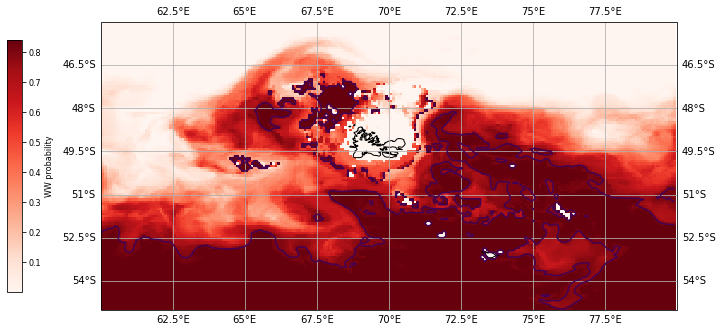

In [196]:
lon,lat=data.variables['longitude'][:],data.variables['latitude'][:]

X,Y=np.meshgrid(lon,lat)

fig=plt.figure(figsize=(10,7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(draw_labels=True)
ax.add_feature(cartopy.feature.LAND)

ax.set_extent([60,80,-45,-55])
im=ax.pcolormesh(X,Y,mask,cmap='Reds',transform=ccrs.PlateCarree())
contour=ax.contour(X,Y,mask,levels=[0.8],transform=ccrs.PlateCarree())


cbar_ax = fig.add_axes([0.02, 0.25, 0.02, 0.5])
cbar=fig.colorbar(im,cax=cbar_ax,orientation='vertical',ticks=[0.1,0.2,0.3,0.4, 0.5,0.6, 0.7,0.8,0.9,1])
cbar.set_label('WW probability',fontsize=8)
cbar.ax.set_yticklabels(['0.1','0.2','0.3','0.4', '0.5','0.6','0.7','0.8','0.9','1'],fontsize=8)

#plt.title('0.083° resolution version')
fig.subplots_adjust(bottom=0.05, top=0.95, left=0.15, right=0.95)

In [197]:
def create_netcdf_2d(lon,lat,data,data_name,data_units,file_name,path_to_save):
    """Creates a NETCDF file from a 2 dimensional array (some time averaged data) with coordinates (lat, lon)"""
    ncout = Dataset(path_to_save+file_name,'w','NETCDF4') # using netCDF3 for output format 
    ncout.createDimension('lon',None)
    ncout.createDimension('lat',None)

    lonvar = ncout.createVariable('lon','float32',('lon'))
    lonvar[:] = lon[:]
    latvar = ncout.createVariable('lat','float32',('lat'))
    latvar[:] = lat[:]

    output_field= ncout.createVariable(data_name,'float32',('lat','lon'))
    output_field.setncattr('units',data_units)
    output_field[:,:] = data[:,:]
    ncout.close();

In [200]:
path_to_save='/home/analivaev/Documents/THESE/Data/Legines/position_PF/'
file_name='WW_prob_presence_{}_week_25-29.nc'.format(year)
print(file_name) # would probably be interesting to compare week25-29 with all weeks

WW_prob_presence_2023_week_25-29.nc


In [201]:
create_netcdf_2d(lon,lat,mask,'WW_prob_presence',data_units='NA',file_name=file_name,path_to_save=path_to_save)